## RF CombinedTraces

Dataset shape: (14271, 18)
Total selected features: 17
Training shape: (9989, 17)
Validation shape: (2141, 17)
Test shape: (2141, 17)


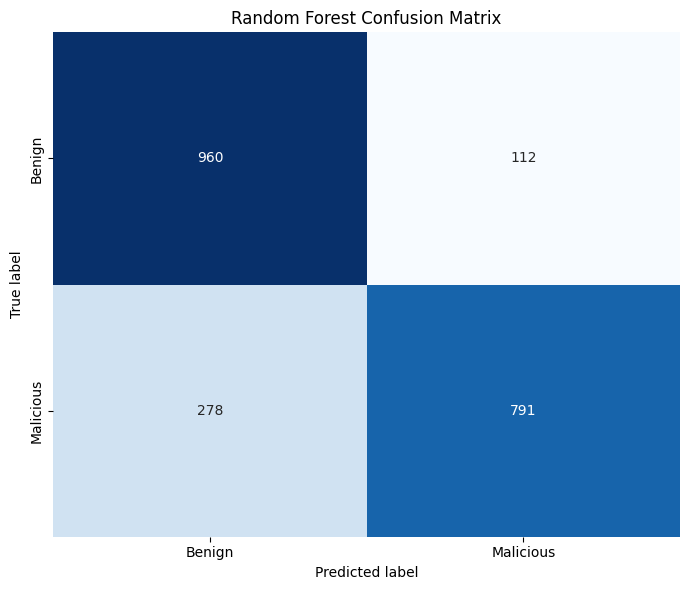

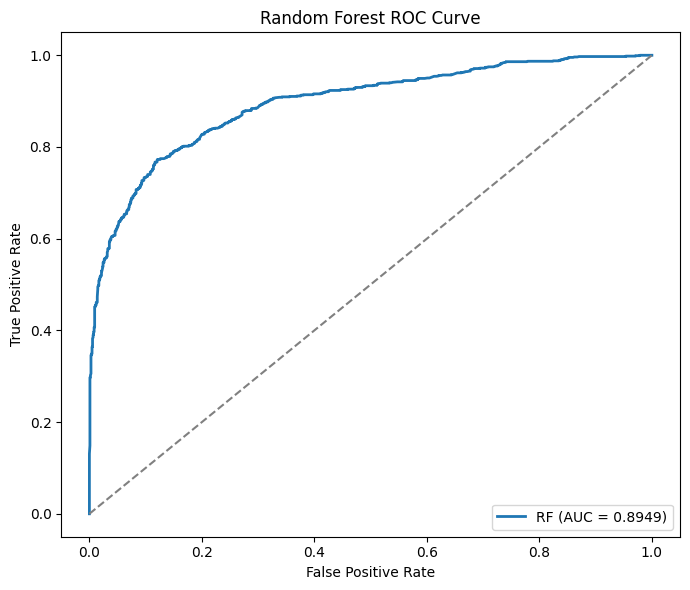


Random Forest results
---------------------------------------------
Train Accuracy: 0.83631995
Validation Accuracy: 0.81083606
Test Accuracy: 0.81784213
Weighted Precision: 0.82563620
Weighted Recall: 0.81784213
Weighted F1 Score: 0.81672031
ROC AUC: 0.89486661
Cohen's Kappa: 0.63560437
Training Time (s): 0.04423177
Validation Prediction Time (s): 0.01330051
Test Prediction Time (s): 0.01310781

Model and preprocessing saved at: RF_best_model_17_features.pkl


In [6]:
import time
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.sparse import csr_matrix, hstack
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_fscore_support,
    cohen_kappa_score
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# ============================================================
# Configuration
# ============================================================

file_path = "FinalCombinedBenignMaliciousDataset-v4 17F.csv"
target_column = "Level"

# 17 selected features
selected_features = [
    "IO_Operations",
    "File_Operations",
    "Time_Operations",
    "Process_Operations",
    "Write_Processes",
    "Read_Data_Transfer",
    "Local_Port_Access",
    "Remote_Port_Access",
    "Total_Dependencies",
    "Direct_Dependencies",
    "Indirect_Dependencies",
    "Pattern_1",
    "Pattern_2",
    "Pattern_3",
    "Pattern_4",
    "Pattern_5",
    "Pattern_6"
]


# ============================================================
# Load and validate dataset
# ============================================================

data = pd.read_csv(file_path)

required_columns = selected_features + [target_column]
missing_columns = [
    column for column in required_columns
    if column not in data.columns
]

if missing_columns:
    raise ValueError(
        f"The following required columns are missing: {missing_columns}"
    )

# Retain only the selected features and target
data = data[required_columns].copy()

X_raw = data[selected_features].copy()
y = data[target_column].copy()


# ============================================================
# Split before fitting preprocessing components
# ============================================================

X_train_raw, X_temp_raw, y_train, y_temp = train_test_split(
    X_raw,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val_raw, X_test_raw, y_val, y_test = train_test_split(
    X_temp_raw,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print(f"Dataset shape: {data.shape}")
print(f"Total selected features: {len(selected_features)}")
print(f"Training shape: {X_train_raw.shape}")
print(f"Validation shape: {X_val_raw.shape}")
print(f"Test shape: {X_test_raw.shape}")


# ============================================================
# Identify categorical and numerical selected features
# ============================================================

categorical_columns = [
    column for column in selected_features
    if X_train_raw[column].dtype == "object"
]

numerical_columns = [
    column for column in selected_features
    if column not in categorical_columns
]


# ============================================================
# Prepare categorical text
# ============================================================

def combine_categorical_columns(frame):
    """Combine selected categorical attributes into one document."""

    if not categorical_columns:
        return pd.Series("", index=frame.index)

    return (
        frame[categorical_columns]
        .fillna("")
        .astype(str)
        .agg(" ".join, axis=1)
    )


train_text = combine_categorical_columns(X_train_raw)
val_text = combine_categorical_columns(X_val_raw)
test_text = combine_categorical_columns(X_test_raw)

# Fit using training data only
vectorizer = CountVectorizer(
    ngram_range=(2, 3),
    lowercase=False
)

X_train_categorical = vectorizer.fit_transform(train_text)
X_val_categorical = vectorizer.transform(val_text)
X_test_categorical = vectorizer.transform(test_text)


# ============================================================
# Prepare numerical features
# ============================================================

def prepare_numerical_features(frame):
    numerical_frame = frame[numerical_columns].copy()

    for column in numerical_columns:
        numerical_frame[column] = pd.to_numeric(
            numerical_frame[column],
            errors="coerce"
        )

    return numerical_frame.fillna(0.0).astype(float)


X_train_numerical = prepare_numerical_features(X_train_raw)
X_val_numerical = prepare_numerical_features(X_val_raw)
X_test_numerical = prepare_numerical_features(X_test_raw)

# Fit scaler using training data only
scaler = StandardScaler(with_mean=False)

X_train_numerical_scaled = scaler.fit_transform(
    csr_matrix(X_train_numerical.values)
)

X_val_numerical_scaled = scaler.transform(
    csr_matrix(X_val_numerical.values)
)

X_test_numerical_scaled = scaler.transform(
    csr_matrix(X_test_numerical.values)
)


# ============================================================
# Combine categorical and numerical inputs
# ============================================================

X_train = hstack(
    [X_train_numerical_scaled, X_train_categorical],
    format="csr"
)

X_val = hstack(
    [X_val_numerical_scaled, X_val_categorical],
    format="csr"
)

X_test = hstack(
    [X_test_numerical_scaled, X_test_categorical],
    format="csr"
)


# ============================================================
# Train Random Forest
# ============================================================

rf_model = RandomForestClassifier(
    n_estimators=10,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

start_train_time = time.perf_counter()
rf_model.fit(X_train, y_train)
train_time = time.perf_counter() - start_train_time


# ============================================================
# Predictions and timing
# ============================================================

y_train_pred = rf_model.predict(X_train)

start_val_time = time.perf_counter()
y_val_pred = rf_model.predict(X_val)
val_time = time.perf_counter() - start_val_time

start_test_time = time.perf_counter()
y_test_pred = rf_model.predict(X_test)
test_time = time.perf_counter() - start_test_time

y_test_probability = rf_model.predict_proba(X_test)[:, 1]


# ============================================================
# Evaluation
# ============================================================

train_accuracy = accuracy_score(y_train, y_train_pred)
validation_accuracy = accuracy_score(y_val, y_val_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

precision, recall, f1, _ = precision_recall_fscore_support(
    y_test,
    y_test_pred,
    average="weighted",
    zero_division=0
)

test_auc = roc_auc_score(y_test, y_test_probability)
kappa = cohen_kappa_score(y_test, y_test_pred)

confusion = confusion_matrix(
    y_test,
    y_test_pred,
    labels=[0, 1]
)

tn, fp, fn, tp = confusion.ravel()


# ============================================================
# Save complete inference pipeline
# ============================================================

model_path = "RF_best_model_17_features.pkl"

model_artifact = {
    "model": rf_model,
    "vectorizer": vectorizer,
    "scaler": scaler,
    "selected_features": selected_features,
    "categorical_columns": categorical_columns,
    "numerical_columns": numerical_columns,
    "target_column": target_column
}

joblib.dump(model_artifact, model_path)


# ============================================================
# Confusion matrix
# ============================================================

plt.figure(figsize=(7, 6))

sns.heatmap(
    confusion,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Benign", "Malicious"],
    yticklabels=["Benign", "Malicious"]
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.savefig("RF_Confusion_Matrix_17F.png", dpi=300)
plt.show()


# ============================================================
# ROC curve
# ============================================================

fpr, tpr, _ = roc_curve(y_test, y_test_probability)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, linewidth=2, label=f"RF (AUC = {test_auc:.4f})")
plt.plot([0, 1], [0, 1], "--", color="grey")
plt.title("Random Forest ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("RF_ROC_Curve_17F.png", dpi=300)
plt.show()


# ============================================================
# Print results
# ============================================================

metrics = {
    "Train Accuracy": train_accuracy,
    "Validation Accuracy": validation_accuracy,
    "Test Accuracy": test_accuracy,
    "Weighted Precision": precision,
    "Weighted Recall": recall,
    "Weighted F1 Score": f1,
    "ROC AUC": test_auc,
    "Cohen's Kappa": kappa,
    "Training Time (s)": train_time,
    "Validation Prediction Time (s)": val_time,
    "Test Prediction Time (s)": test_time
}

print("\nRandom Forest results")
print("-" * 45)

for metric, value in metrics.items():
    if isinstance(value, (int,)):
        print(f"{metric}: {value}")
    else:
        print(f"{metric}: {value:.8f}")

print(f"\nModel and preprocessing saved at: {model_path}")

## DT CombinedTraces

Dataset shape: (14271, 18)
Total selected features: 17
Training shape: (9989, 17)
Validation shape: (2141, 17)
Test shape: (2141, 17)


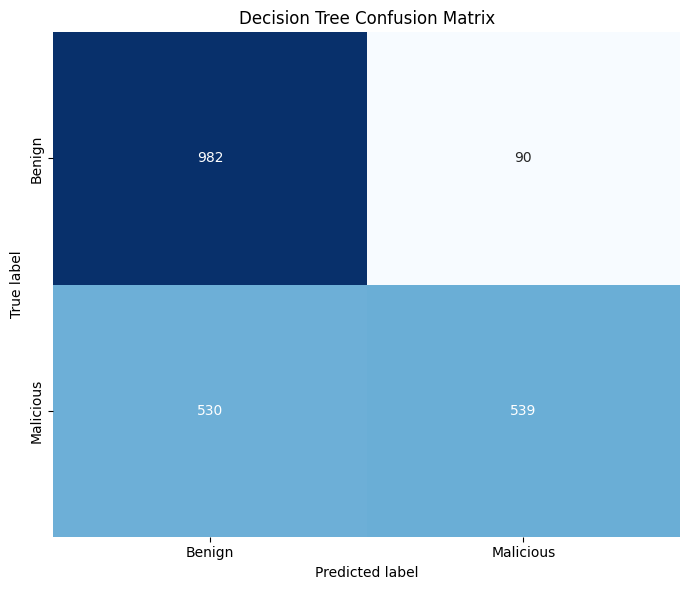

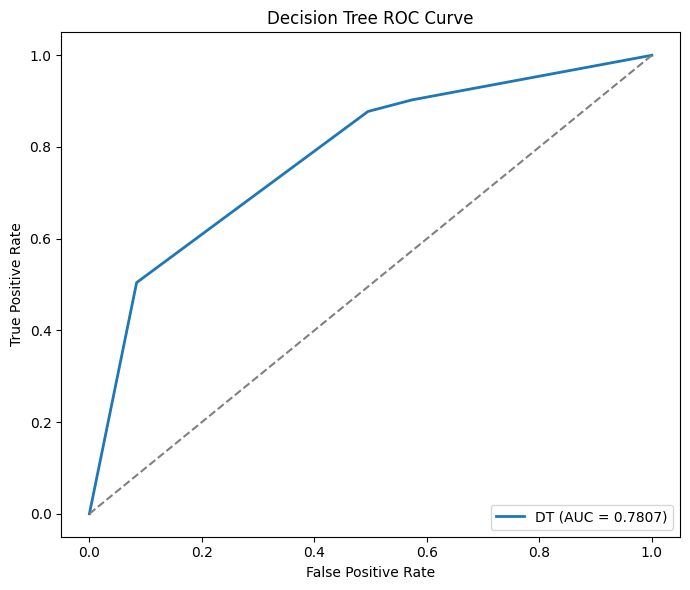


Decision Tree results
---------------------------------------------
Train Accuracy: 0.71208329
Validation Accuracy: 0.70621205
Test Accuracy: 0.71041569
Weighted Precision: 0.75304798
Weighted Recall: 0.71041569
Weighted F1 Score: 0.69755095
ROC AUC: 0.78067494
Cohen's Kappa: 0.42049650
Training Time (s): 0.01882114
Validation Prediction Time (s): 0.00051321
Test Prediction Time (s): 0.00045530

Model and preprocessing saved at: DT_best_model_17_features.pkl


In [5]:
import time
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.sparse import csr_matrix, hstack
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_fscore_support,
    cohen_kappa_score
)


# ============================================================
# Configuration
# ============================================================

file_path = "FinalCombinedBenignMaliciousDataset-v4 17F.csv"
target_column = "Level"

# Exactly 17 selected features
selected_features = [
    "IO_Operations",
    "File_Operations",
    "Time_Operations",
    "Process_Operations",
    "Write_Processes",
    "Read_Data_Transfer",
    "Local_Port_Access",
    "Remote_Port_Access",
    "Total_Dependencies",
    "Direct_Dependencies",
    "Indirect_Dependencies",
    "Pattern_1",
    "Pattern_2",
    "Pattern_3",
    "Pattern_4",
    "Pattern_5",
    "Pattern_6"
]


# ============================================================
# Load and validate dataset
# ============================================================

data = pd.read_csv(file_path)

required_columns = selected_features + [target_column]

missing_columns = [
    column for column in required_columns
    if column not in data.columns
]

if missing_columns:
    raise ValueError(
        f"The following required columns are missing: {missing_columns}"
    )

# Retain only the selected features and target
data = data[required_columns].copy()

X_raw = data[selected_features].copy()
y = data[target_column].copy()

# ============================================================
# Split before preprocessing
# ============================================================

X_train_raw, X_temp_raw, y_train, y_temp = train_test_split(
    X_raw,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val_raw, X_test_raw, y_val, y_test = train_test_split(
    X_temp_raw,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print(f"Dataset shape: {data.shape}")
print(f"Total selected features: {len(selected_features)}")
print(f"Training shape: {X_train_raw.shape}")
print(f"Validation shape: {X_val_raw.shape}")
print(f"Test shape: {X_test_raw.shape}")

# ============================================================
# Identify categorical and numerical features
# ============================================================

categorical_columns = [
    column for column in selected_features
    if X_train_raw[column].dtype == "object"
]

numerical_columns = [
    column for column in selected_features
    if column not in categorical_columns
]


# ============================================================
# Prepare categorical features
# ============================================================

def combine_categorical_columns(frame):
    """Combine selected categorical attributes into one document."""

    if not categorical_columns:
        return pd.Series("", index=frame.index)

    return (
        frame[categorical_columns]
        .fillna("")
        .astype(str)
        .agg(" ".join, axis=1)
    )


train_text = combine_categorical_columns(X_train_raw)
validation_text = combine_categorical_columns(X_val_raw)
test_text = combine_categorical_columns(X_test_raw)

# Fit only on training data
vectorizer = CountVectorizer(
    ngram_range=(2, 3),
    lowercase=False
)

X_train_categorical = vectorizer.fit_transform(train_text)
X_val_categorical = vectorizer.transform(validation_text)
X_test_categorical = vectorizer.transform(test_text)


# ============================================================
# Prepare numerical features
# ============================================================

def prepare_numerical_features(frame):
    numerical_frame = frame[numerical_columns].copy()

    for column in numerical_columns:
        numerical_frame[column] = pd.to_numeric(
            numerical_frame[column],
            errors="coerce"
        )

    return numerical_frame.fillna(0.0).astype(float)


X_train_numerical = prepare_numerical_features(X_train_raw)
X_val_numerical = prepare_numerical_features(X_val_raw)
X_test_numerical = prepare_numerical_features(X_test_raw)

# Fit scaler only on training data
scaler = StandardScaler(with_mean=False)

X_train_numerical_scaled = scaler.fit_transform(
    csr_matrix(X_train_numerical.values)
)

X_val_numerical_scaled = scaler.transform(
    csr_matrix(X_val_numerical.values)
)

X_test_numerical_scaled = scaler.transform(
    csr_matrix(X_test_numerical.values)
)


# ============================================================
# Combine categorical and numerical features
# ============================================================

X_train = hstack(
    [X_train_numerical_scaled, X_train_categorical],
    format="csr"
)

X_val = hstack(
    [X_val_numerical_scaled, X_val_categorical],
    format="csr"
)

X_test = hstack(
    [X_test_numerical_scaled, X_test_categorical],
    format="csr"
)


# ============================================================
# Initialize and train Decision Tree
# ============================================================

dt_model = DecisionTreeClassifier(
    max_depth=2,
    min_samples_split=20,
    random_state=42
)

start_train_time = time.perf_counter()
dt_model.fit(X_train, y_train)
training_time = time.perf_counter() - start_train_time


# ============================================================
# Predictions and timing
# ============================================================

y_train_pred = dt_model.predict(X_train)

start_validation_time = time.perf_counter()
y_val_pred = dt_model.predict(X_val)
validation_time = time.perf_counter() - start_validation_time

start_test_time = time.perf_counter()
y_test_pred = dt_model.predict(X_test)
test_time = time.perf_counter() - start_test_time

y_test_probability = dt_model.predict_proba(X_test)[:, 1]


# ============================================================
# Calculate evaluation metrics
# ============================================================

train_accuracy = accuracy_score(y_train, y_train_pred)
validation_accuracy = accuracy_score(y_val, y_val_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

precision, recall, f1, _ = precision_recall_fscore_support(
    y_test,
    y_test_pred,
    average="weighted",
    zero_division=0
)

test_auc = roc_auc_score(y_test, y_test_probability)
kappa = cohen_kappa_score(y_test, y_test_pred)

confusion = confusion_matrix(
    y_test,
    y_test_pred,
    labels=[0, 1]
)

tn, fp, fn, tp = confusion.ravel()


# ============================================================
# Save complete inference pipeline
# ============================================================

model_path = "DT_best_model_17_features.pkl"

model_artifact = {
    "model": dt_model,
    "vectorizer": vectorizer,
    "scaler": scaler,
    "selected_features": selected_features,
    "categorical_columns": categorical_columns,
    "numerical_columns": numerical_columns,
    "target_column": target_column
}

joblib.dump(model_artifact, model_path)


# ============================================================
# Confusion matrix
# ============================================================

plt.figure(figsize=(7, 6))

sns.heatmap(
    confusion,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Benign", "Malicious"],
    yticklabels=["Benign", "Malicious"]
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.savefig(
    "DT_Confusion_Matrix_17F.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


# ============================================================
# ROC curve
# ============================================================

fpr, tpr, _ = roc_curve(y_test, y_test_probability)

plt.figure(figsize=(7, 6))
plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"DT (AUC = {test_auc:.4f})"
)
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="grey"
)

plt.title("Decision Tree ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(
    "DT_ROC_Curve_17F.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


# ============================================================
# Print results
# ============================================================

metrics = {
    "Train Accuracy": train_accuracy,
    "Validation Accuracy": validation_accuracy,
    "Test Accuracy": test_accuracy,
    "Weighted Precision": precision,
    "Weighted Recall": recall,
    "Weighted F1 Score": f1,
    "ROC AUC": test_auc,
    "Cohen's Kappa": kappa,
    "Training Time (s)": training_time,
    "Validation Prediction Time (s)": validation_time,
    "Test Prediction Time (s)": test_time
}

print("\nDecision Tree results")
print("-" * 45)

for metric, value in metrics.items():
    if isinstance(value, (int,)):
        print(f"{metric}: {value}")
    else:
        print(f"{metric}: {value:.8f}")

print(f"\nModel and preprocessing saved at: {model_path}")

## SVM CombinedTraces

Dataset shape: (14271, 18)
Total selected features: 17
Training shape: (9989, 17)
Validation shape: (2141, 17)
Test shape: (2141, 17)


/home/n11894571/miniconda3/envs/tf211gpu/lib/python3.10/site-packages/sklearn/svm/_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


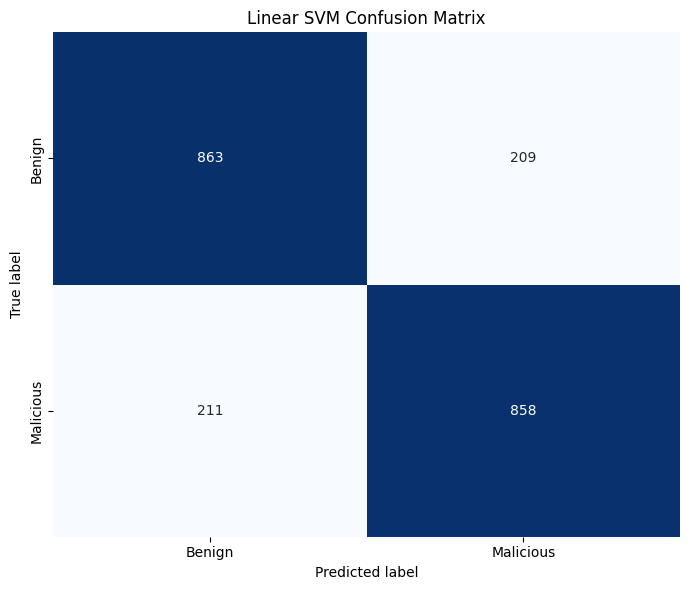

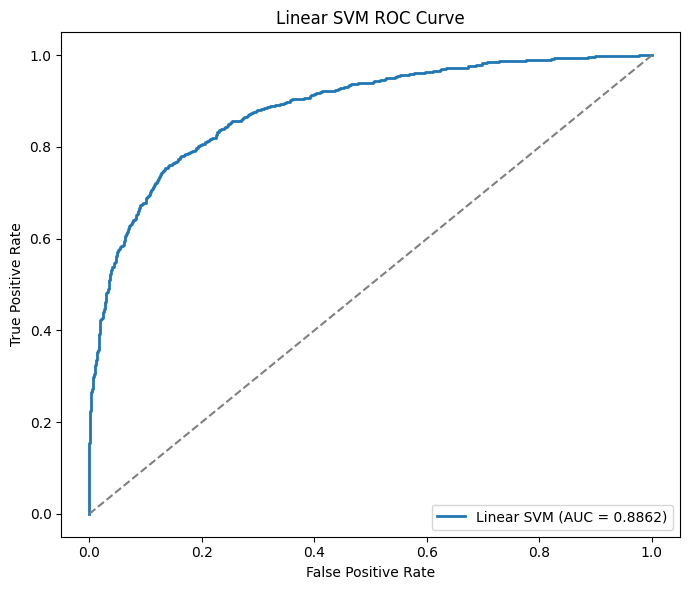


 SVM results
--------------------------------------------------
Train Accuracy: 0.89878867
Validation Accuracy: 0.80616534
Test Accuracy: 0.80382999
Weighted Precision: 0.80383053
Weighted Recall: 0.80382999
Weighted F1 Score: 0.80382956
ROC AUC: 0.88621148
Cohen's Kappa: 0.60765817
Training Time (s): 3.28202815
Training Prediction Time (s): 0.00164201
Validation Prediction Time (s): 0.00039191
Test Prediction Time (s): 0.00028470

Model saved at: LinearSVM_17F_efficient.pkl


In [7]:
import time
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.sparse import csr_matrix, hstack
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_fscore_support,
    cohen_kappa_score
)


# ============================================================
# Configuration
# ============================================================

file_path = "FinalCombinedBenignMaliciousDataset-v4 17F.csv"
target_column = "Level"

selected_features = [
    "IO_Operations",
    "File_Operations",
    "Time_Operations",
    "Process_Operations",
    "Write_Processes",
    "Read_Data_Transfer",
    "Local_Port_Access",
    "Remote_Port_Access",
    "Total_Dependencies",
    "Direct_Dependencies",
    "Indirect_Dependencies",
    "Pattern_1",
    "Pattern_2",
    "Pattern_3",
    "Pattern_4",
    "Pattern_5",
    "Pattern_6"
]


# ============================================================
# Load and validate data
# ============================================================

data = pd.read_csv(
    file_path,
    usecols=selected_features + [target_column]
)

missing_columns = [
    column for column in selected_features + [target_column]
    if column not in data.columns
]

if missing_columns:
    raise ValueError(f"Missing columns: {missing_columns}")

X_raw = data[selected_features]
y = data[target_column]


# ============================================================
# Split before preprocessing
# ============================================================

X_train_raw, X_temp_raw, y_train, y_temp = train_test_split(
    X_raw,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val_raw, X_test_raw, y_val, y_test = train_test_split(
    X_temp_raw,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print(f"Dataset shape: {data.shape}")
print(f"Total selected features: {len(selected_features)}")
print(f"Training shape: {X_train_raw.shape}")
print(f"Validation shape: {X_val_raw.shape}")
print(f"Test shape: {X_test_raw.shape}")


# ============================================================
# Identify feature types
# ============================================================

categorical_columns = X_train_raw.select_dtypes(
    include=["object", "string"]
).columns.tolist()

numerical_columns = [
    column for column in selected_features
    if column not in categorical_columns
]


# ============================================================
# Categorical preprocessing
# ============================================================

def combine_text(frame):
    if not categorical_columns:
        return pd.Series("", index=frame.index)

    return (
        frame[categorical_columns]
        .fillna("")
        .astype(str)
        .agg(" ".join, axis=1)
    )


train_text = combine_text(X_train_raw)
val_text = combine_text(X_val_raw)
test_text = combine_text(X_test_raw)

vectorizer = CountVectorizer(
    ngram_range=(2, 3),
    min_df=2,            
    max_features=20000,   
    lowercase=False,
    dtype="float32"
)

X_train_text = vectorizer.fit_transform(train_text)
X_val_text = vectorizer.transform(val_text)
X_test_text = vectorizer.transform(test_text)


# ============================================================
# Numerical preprocessing
# ============================================================

def prepare_numeric(frame):
    numeric = frame[numerical_columns].apply(
        pd.to_numeric,
        errors="coerce"
    )

    return numeric.fillna(0).astype("float32")


train_numeric = prepare_numeric(X_train_raw)
val_numeric = prepare_numeric(X_val_raw)
test_numeric = prepare_numeric(X_test_raw)

# Scale numerical attributes only
numeric_scaler = StandardScaler()

X_train_numeric = numeric_scaler.fit_transform(train_numeric)
X_val_numeric = numeric_scaler.transform(val_numeric)
X_test_numeric = numeric_scaler.transform(test_numeric)


# ============================================================
# Combine sparse inputs
# ============================================================

X_train = hstack(
    [csr_matrix(X_train_numeric), X_train_text],
    format="csr",
    dtype="float32"
)

X_val = hstack(
    [csr_matrix(X_val_numeric), X_val_text],
    format="csr",
    dtype="float32"
)

X_test = hstack(
    [csr_matrix(X_test_numeric), X_test_text],
    format="csr",
    dtype="float32"
)


# ============================================================
# Train efficient linear SVM
# ============================================================

svm_model = LinearSVC(
    C=1.0,
    class_weight=None,
    dual=True,
    max_iter=5000,
    random_state=42
)

start = time.perf_counter()
svm_model.fit(X_train, y_train)
training_time = time.perf_counter() - start


# ============================================================
# Predictions and timing
# ============================================================

start = time.perf_counter()
y_train_pred = svm_model.predict(X_train)
training_prediction_time = time.perf_counter() - start

start = time.perf_counter()
y_val_pred = svm_model.predict(X_val)
validation_time = time.perf_counter() - start

start = time.perf_counter()
y_test_pred = svm_model.predict(X_test)
test_time = time.perf_counter() - start

# Continuous scores for ROC-AUC; probabilities are unnecessary
y_test_score = svm_model.decision_function(X_test)


# ============================================================
# Metrics
# ============================================================

train_accuracy = accuracy_score(y_train, y_train_pred)
validation_accuracy = accuracy_score(y_val, y_val_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

precision, recall, f1, _ = precision_recall_fscore_support(
    y_test,
    y_test_pred,
    average="weighted",
    zero_division=0
)

test_auc = roc_auc_score(y_test, y_test_score)
kappa = cohen_kappa_score(y_test, y_test_pred)

confusion = confusion_matrix(
    y_test,
    y_test_pred,
    labels=[0, 1]
)

tn, fp, fn, tp = confusion.ravel()


# ============================================================
# Save model and preprocessing
# ============================================================

model_path = "LinearSVM_17F_efficient.pkl"

artifact = {
    "model": svm_model,
    "vectorizer": vectorizer,
    "numeric_scaler": numeric_scaler,
    "selected_features": selected_features,
    "categorical_columns": categorical_columns,
    "numerical_columns": numerical_columns,
    "target_column": target_column
}

joblib.dump(
    artifact,
    model_path,
    compress=3
)


# ============================================================
# Confusion matrix
# ============================================================

plt.figure(figsize=(7, 6))

sns.heatmap(
    confusion,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Benign", "Malicious"],
    yticklabels=["Benign", "Malicious"]
)

plt.title("Linear SVM Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.savefig(
    "LinearSVM_Confusion_Matrix_17F.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


# ============================================================
# ROC curve
# ============================================================

fpr, tpr, _ = roc_curve(y_test, y_test_score)

plt.figure(figsize=(7, 6))
plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"Linear SVM (AUC = {test_auc:.4f})"
)
plt.plot(
    [0, 1],
    [0, 1],
    "--",
    color="grey"
)

plt.title("Linear SVM ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(
    "LinearSVM_ROC_Curve_17F.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


# ============================================================
# Print results
# ============================================================

metrics = {
    "Train Accuracy": train_accuracy,
    "Validation Accuracy": validation_accuracy,
    "Test Accuracy": test_accuracy,
    "Weighted Precision": precision,
    "Weighted Recall": recall,
    "Weighted F1 Score": f1,
    "ROC AUC": test_auc,
    "Cohen's Kappa": kappa,
    "Training Time (s)": training_time,
    "Training Prediction Time (s)": training_prediction_time,
    "Validation Prediction Time (s)": validation_time,
    "Test Prediction Time (s)": test_time
}

print("\n SVM results")
print("-" * 50)

for metric, value in metrics.items():
    if metric in {
        "True Negatives",
        "False Positives",
        "False Negatives",
        "True Positives"
    }:
        print(f"{metric}: {int(value)}")
    else:
        print(f"{metric}: {value:.8f}")

print(f"\nModel saved at: {model_path}")

## LR CombinedTraces

Dataset shape: (14271, 18)
Total selected features: 17
Training shape: (9989, 17)
Validation shape: (2141, 17)
Test shape: (2141, 17)


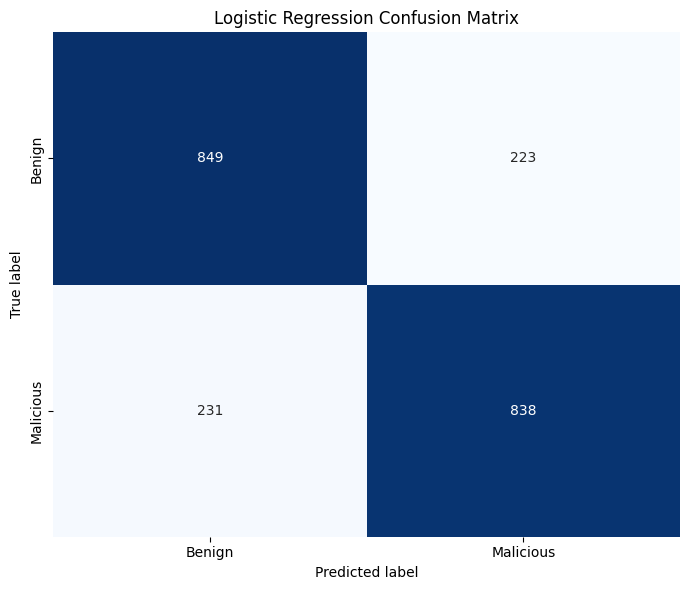

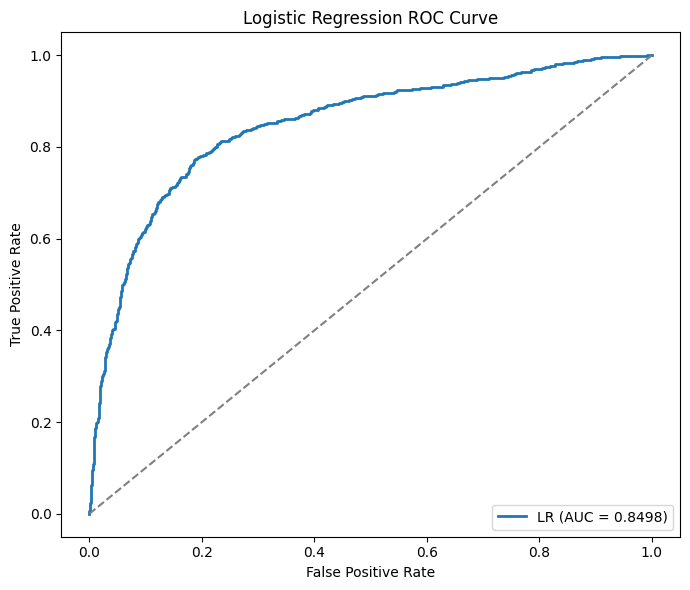


Logistic Regression results
---------------------------------------------
Train Accuracy: 0.90119131
Validation Accuracy: 0.79262027
Test Accuracy: 0.78794956
Weighted Precision: 0.78796342
Weighted Recall: 0.78794956
Weighted F1 Score: 0.78794549
ROC AUC: 0.84976195
Cohen's Kappa: 0.57589384
Training Time (s): 0.60816317
Validation Prediction Time (s): 0.00037494
Test Prediction Time (s): 0.00032989

Model and preprocessing saved at: LR_best_model_17_features.pkl


In [8]:
import time
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.sparse import csr_matrix, hstack
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_fscore_support,
    cohen_kappa_score
)


# ============================================================
# Configuration
# ============================================================

file_path = "FinalCombinedBenignMaliciousDataset-v4 17F.csv"
target_column = "Level"

selected_features = [
    "IO_Operations",
    "File_Operations",
    "Time_Operations",
    "Process_Operations",
    "Write_Processes",
    "Read_Data_Transfer",
    "Local_Port_Access",
    "Remote_Port_Access",
    "Total_Dependencies",
    "Direct_Dependencies",
    "Indirect_Dependencies",
    "Pattern_1",
    "Pattern_2",
    "Pattern_3",
    "Pattern_4",
    "Pattern_5",
    "Pattern_6"
]


# ============================================================
# Load and validate dataset
# ============================================================

data = pd.read_csv(file_path)

required_columns = selected_features + [target_column]

missing_columns = [
    column for column in required_columns
    if column not in data.columns
]

if missing_columns:
    raise ValueError(
        f"The following required columns are missing: {missing_columns}"
    )

# Keep only the selected predictors and target
data = data[required_columns].copy()

X_raw = data[selected_features].copy()
y = data[target_column].copy()


# ============================================================
# Split before preprocessing
# ============================================================

X_train_raw, X_temp_raw, y_train, y_temp = train_test_split(
    X_raw,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val_raw, X_test_raw, y_val, y_test = train_test_split(
    X_temp_raw,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print(f"Dataset shape: {data.shape}")
print(f"Total selected features: {len(selected_features)}")
print(f"Training shape: {X_train_raw.shape}")
print(f"Validation shape: {X_val_raw.shape}")
print(f"Test shape: {X_test_raw.shape}")


# ============================================================
# Identify categorical and numerical features
# ============================================================

categorical_columns = [
    column for column in selected_features
    if X_train_raw[column].dtype == "object"
]

numerical_columns = [
    column for column in selected_features
    if column not in categorical_columns
]


# ============================================================
# Prepare categorical features
# ============================================================

def combine_categorical_columns(frame):
    """Combine selected categorical attributes into one document."""

    if not categorical_columns:
        return pd.Series("", index=frame.index)

    return (
        frame[categorical_columns]
        .fillna("")
        .astype(str)
        .agg(" ".join, axis=1)
    )


train_text = combine_categorical_columns(X_train_raw)
validation_text = combine_categorical_columns(X_val_raw)
test_text = combine_categorical_columns(X_test_raw)

# Fit the vectorizer only on training data
vectorizer = CountVectorizer(
    ngram_range=(2, 3),
    lowercase=False
)

X_train_categorical = vectorizer.fit_transform(train_text)
X_val_categorical = vectorizer.transform(validation_text)
X_test_categorical = vectorizer.transform(test_text)


# ============================================================
# Prepare numerical features
# ============================================================

def prepare_numerical_features(frame):
    numerical_frame = frame[numerical_columns].copy()

    for column in numerical_columns:
        numerical_frame[column] = pd.to_numeric(
            numerical_frame[column],
            errors="coerce"
        )

    return numerical_frame.fillna(0.0).astype(float)


X_train_numerical = prepare_numerical_features(X_train_raw)
X_val_numerical = prepare_numerical_features(X_val_raw)
X_test_numerical = prepare_numerical_features(X_test_raw)

X_train_numerical_sparse = csr_matrix(
    X_train_numerical.values
)

X_val_numerical_sparse = csr_matrix(
    X_val_numerical.values
)

X_test_numerical_sparse = csr_matrix(
    X_test_numerical.values
)


# ============================================================
# Combine numerical and categorical features
# ============================================================

X_train_combined = hstack(
    [X_train_numerical_sparse, X_train_categorical],
    format="csr"
)

X_val_combined = hstack(
    [X_val_numerical_sparse, X_val_categorical],
    format="csr"
)

X_test_combined = hstack(
    [X_test_numerical_sparse, X_test_categorical],
    format="csr"
)


# ============================================================
# Scale combined features
# ============================================================

# Fit only on training data. with_mean=False preserves sparsity.
scaler = StandardScaler(with_mean=False)

X_train = scaler.fit_transform(X_train_combined)
X_val = scaler.transform(X_val_combined)
X_test = scaler.transform(X_test_combined)


# ============================================================
# Initialize and train Logistic Regression
# ============================================================

lr_model = LogisticRegression(
    random_state=42,
    max_iter=2500,
    solver="liblinear"
)

start_train_time = time.perf_counter()
lr_model.fit(X_train, y_train)
training_time = time.perf_counter() - start_train_time


# ============================================================
# Predictions and prediction times
# ============================================================

y_train_pred = lr_model.predict(X_train)

start_validation_time = time.perf_counter()
y_val_pred = lr_model.predict(X_val)
validation_time = time.perf_counter() - start_validation_time

start_test_time = time.perf_counter()
y_test_pred = lr_model.predict(X_test)
test_time = time.perf_counter() - start_test_time

y_test_probability = lr_model.predict_proba(X_test)[:, 1]


# ============================================================
# Evaluation metrics
# ============================================================

train_accuracy = accuracy_score(y_train, y_train_pred)
validation_accuracy = accuracy_score(y_val, y_val_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

precision, recall, f1, _ = precision_recall_fscore_support(
    y_test,
    y_test_pred,
    average="weighted",
    zero_division=0
)

test_auc = roc_auc_score(y_test, y_test_probability)
kappa = cohen_kappa_score(y_test, y_test_pred)

confusion = confusion_matrix(
    y_test,
    y_test_pred,
    labels=[0, 1]
)

tn, fp, fn, tp = confusion.ravel()


# ============================================================
# Save complete inference pipeline
# ============================================================

model_path = "LR_best_model_17_features.pkl"

model_artifact = {
    "model": lr_model,
    "vectorizer": vectorizer,
    "scaler": scaler,
    "selected_features": selected_features,
    "categorical_columns": categorical_columns,
    "numerical_columns": numerical_columns,
    "target_column": target_column
}

joblib.dump(model_artifact, model_path)


# ============================================================
# Confusion matrix
# ============================================================

plt.figure(figsize=(7, 6))

sns.heatmap(
    confusion,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Benign", "Malicious"],
    yticklabels=["Benign", "Malicious"]
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()

plt.savefig(
    "LR_Confusion_Matrix_17F.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# ROC curve
# ============================================================

fpr, tpr, _ = roc_curve(
    y_test,
    y_test_probability
)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"LR (AUC = {test_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="grey"
)

plt.title("Logistic Regression ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()

plt.savefig(
    "LR_ROC_Curve_17F.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# Print results
# ============================================================

metrics = {
    "Train Accuracy": train_accuracy,
    "Validation Accuracy": validation_accuracy,
    "Test Accuracy": test_accuracy,
    "Weighted Precision": precision,
    "Weighted Recall": recall,
    "Weighted F1 Score": f1,
    "ROC AUC": test_auc,
    "Cohen's Kappa": kappa,
    "Training Time (s)": training_time,
    "Validation Prediction Time (s)": validation_time,
    "Test Prediction Time (s)": test_time
}

print("\nLogistic Regression results")
print("-" * 45)

for metric, value in metrics.items():
    if isinstance(value, (int,)):
        print(f"{metric}: {value}")
    else:
        print(f"{metric}: {value:.8f}")

print(f"\nModel and preprocessing saved at: {model_path}")

## KNN CombinedTraces

Dataset shape: (14271, 18)
Total selected features: 17
Training shape: (9989, 17)
Validation shape: (2141, 17)
Test shape: (2141, 17)


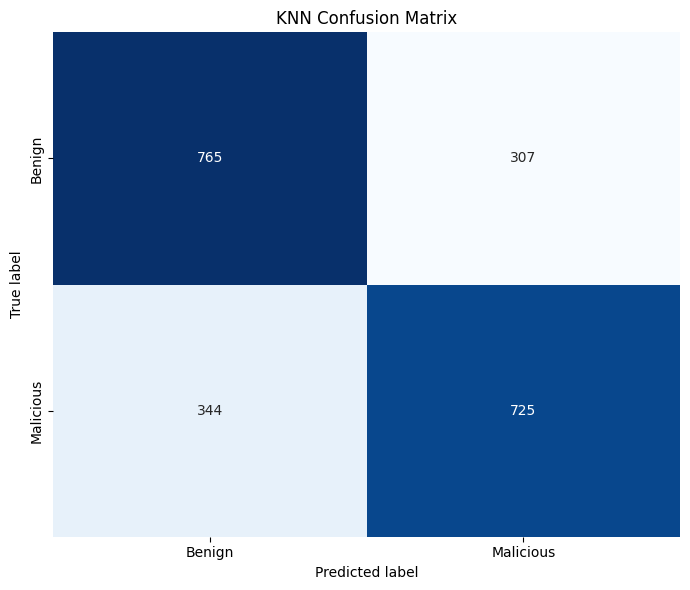

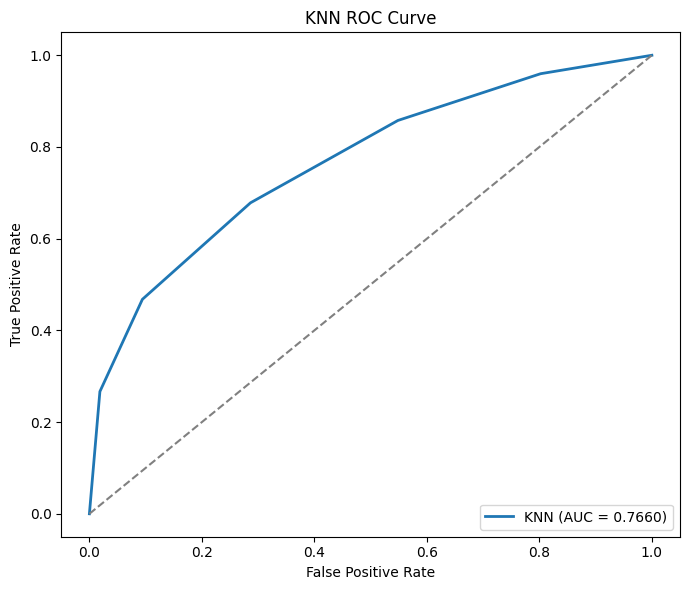


KNN results
---------------------------------------------
Train Accuracy: 0.80919011
Validation Accuracy: 0.67958898
Test Accuracy: 0.69593648
Weighted Precision: 0.69615611
Weighted Recall: 0.69593648
Weighted F1 Score: 0.69583827
ROC AUC: 0.76602183
Cohen's Kappa: 0.39184231
Training Time (s): 0.00168247
Validation Prediction Time (s): 4.59465264
Test Prediction Time (s): 4.63216955

Model and preprocessing saved at: KNN_best_model_17_features.pkl


In [9]:
import time
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.sparse import csr_matrix, hstack
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_fscore_support,
    cohen_kappa_score
)


# ============================================================
# Configuration
# ============================================================

file_path = "FinalCombinedBenignMaliciousDataset-v4 17F.csv"
target_column = "Level"

selected_features = [
    "IO_Operations",
    "File_Operations",
    "Time_Operations",
    "Process_Operations",
    "Write_Processes",
    "Read_Data_Transfer",
    "Local_Port_Access",
    "Remote_Port_Access",
    "Total_Dependencies",
    "Direct_Dependencies",
    "Indirect_Dependencies",
    "Pattern_1",
    "Pattern_2",
    "Pattern_3",
    "Pattern_4",
    "Pattern_5",
    "Pattern_6"
]


# ============================================================
# Load and validate dataset
# ============================================================

data = pd.read_csv(file_path)

required_columns = selected_features + [target_column]

missing_columns = [
    column for column in required_columns
    if column not in data.columns
]

if missing_columns:
    raise ValueError(
        f"The following required columns are missing: {missing_columns}"
    )

# Retain only the selected features and target
data = data[required_columns].copy()

X_raw = data[selected_features].copy()
y = data[target_column].copy()


# ============================================================
# Split before preprocessing
# ============================================================

X_train_raw, X_temp_raw, y_train, y_temp = train_test_split(
    X_raw,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val_raw, X_test_raw, y_val, y_test = train_test_split(
    X_temp_raw,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print(f"Dataset shape: {data.shape}")
print(f"Total selected features: {len(selected_features)}")
print(f"Training shape: {X_train_raw.shape}")
print(f"Validation shape: {X_val_raw.shape}")
print(f"Test shape: {X_test_raw.shape}")


# ============================================================
# Identify categorical and numerical features
# ============================================================

categorical_columns = [
    column for column in selected_features
    if X_train_raw[column].dtype == "object"
]

numerical_columns = [
    column for column in selected_features
    if column not in categorical_columns
]


# ============================================================
# Prepare categorical features
# ============================================================

def combine_categorical_columns(frame):
    """Combine selected categorical attributes into one document."""

    if not categorical_columns:
        return pd.Series("", index=frame.index)

    return (
        frame[categorical_columns]
        .fillna("")
        .astype(str)
        .agg(" ".join, axis=1)
    )


train_text = combine_categorical_columns(X_train_raw)
validation_text = combine_categorical_columns(X_val_raw)
test_text = combine_categorical_columns(X_test_raw)

# Fit vectorizer only on the training data
vectorizer = CountVectorizer(
    ngram_range=(2, 3),
    lowercase=False
)

X_train_categorical = vectorizer.fit_transform(train_text)
X_val_categorical = vectorizer.transform(validation_text)
X_test_categorical = vectorizer.transform(test_text)


# ============================================================
# Prepare numerical features
# ============================================================

def prepare_numerical_features(frame):
    numerical_frame = frame[numerical_columns].copy()

    for column in numerical_columns:
        numerical_frame[column] = pd.to_numeric(
            numerical_frame[column],
            errors="coerce"
        )

    return numerical_frame.fillna(0.0).astype(float)


X_train_numerical = prepare_numerical_features(X_train_raw)
X_val_numerical = prepare_numerical_features(X_val_raw)
X_test_numerical = prepare_numerical_features(X_test_raw)

X_train_numerical_sparse = csr_matrix(
    X_train_numerical.values
)

X_val_numerical_sparse = csr_matrix(
    X_val_numerical.values
)

X_test_numerical_sparse = csr_matrix(
    X_test_numerical.values
)


# ============================================================
# Combine numerical and categorical inputs
# ============================================================

X_train_combined = hstack(
    [X_train_numerical_sparse, X_train_categorical],
    format="csr"
)

X_val_combined = hstack(
    [X_val_numerical_sparse, X_val_categorical],
    format="csr"
)

X_test_combined = hstack(
    [X_test_numerical_sparse, X_test_categorical],
    format="csr"
)


# ============================================================
# Scale combined features
# ============================================================

# KNN is distance-based, so feature scaling is important.
# with_mean=False preserves sparse matrix representation.
scaler = StandardScaler(with_mean=False)

X_train = scaler.fit_transform(X_train_combined)
X_val = scaler.transform(X_val_combined)
X_test = scaler.transform(X_test_combined)


# ============================================================
# Initialize and train KNN
# ============================================================

knn_model = KNeighborsClassifier(
    n_neighbors=5,
    weights="uniform",
    metric="minkowski",
    p=2,
    algorithm="brute",
    n_jobs=-1
)

start_train_time = time.perf_counter()
knn_model.fit(X_train, y_train)
training_time = time.perf_counter() - start_train_time


# ============================================================
# Predictions and prediction times
# ============================================================

y_train_pred = knn_model.predict(X_train)

start_validation_time = time.perf_counter()
y_val_pred = knn_model.predict(X_val)
validation_time = time.perf_counter() - start_validation_time

start_test_time = time.perf_counter()
y_test_pred = knn_model.predict(X_test)
test_time = time.perf_counter() - start_test_time

y_test_probability = knn_model.predict_proba(X_test)[:, 1]


# ============================================================
# Evaluation metrics
# ============================================================

train_accuracy = accuracy_score(y_train, y_train_pred)
validation_accuracy = accuracy_score(y_val, y_val_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

precision, recall, f1, _ = precision_recall_fscore_support(
    y_test,
    y_test_pred,
    average="weighted",
    zero_division=0
)

test_auc = roc_auc_score(y_test, y_test_probability)
kappa = cohen_kappa_score(y_test, y_test_pred)

confusion = confusion_matrix(
    y_test,
    y_test_pred,
    labels=[0, 1]
)

tn, fp, fn, tp = confusion.ravel()


# ============================================================
# Save complete inference pipeline
# ============================================================

model_path = "KNN_best_model_17_features.pkl"

model_artifact = {
    "model": knn_model,
    "vectorizer": vectorizer,
    "scaler": scaler,
    "selected_features": selected_features,
    "categorical_columns": categorical_columns,
    "numerical_columns": numerical_columns,
    "target_column": target_column
}

joblib.dump(model_artifact, model_path)


# ============================================================
# Confusion matrix
# ============================================================

plt.figure(figsize=(7, 6))

sns.heatmap(
    confusion,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Benign", "Malicious"],
    yticklabels=["Benign", "Malicious"]
)

plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()

plt.savefig(
    "KNN_Confusion_Matrix_17F.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# ROC curve
# ============================================================

fpr, tpr, _ = roc_curve(
    y_test,
    y_test_probability
)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"KNN (AUC = {test_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="grey"
)

plt.title("KNN ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()

plt.savefig(
    "KNN_ROC_Curve_17F.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# Print results
# ============================================================

metrics = {
    "Train Accuracy": train_accuracy,
    "Validation Accuracy": validation_accuracy,
    "Test Accuracy": test_accuracy,
    "Weighted Precision": precision,
    "Weighted Recall": recall,
    "Weighted F1 Score": f1,
    "ROC AUC": test_auc,
    "Cohen's Kappa": kappa,
    "Training Time (s)": training_time,
    "Validation Prediction Time (s)": validation_time,
    "Test Prediction Time (s)": test_time
}

print("\nKNN results")
print("-" * 45)

for metric, value in metrics.items():
    if isinstance(value, (int,)):
        print(f"{metric}: {value}")
    else:
        print(f"{metric}: {value:.8f}")

print(f"\nModel and preprocessing saved at: {model_path}")

## GB CombinedTraces

Dataset shape: (14271, 18)
Total selected features: 17
Training shape: (9989, 17)
Validation shape: (2141, 17)
Test shape: (2141, 17)
Training matrix memory: 475.86 MB
Validation matrix memory: 101.99 MB
Test matrix memory: 101.99 MB


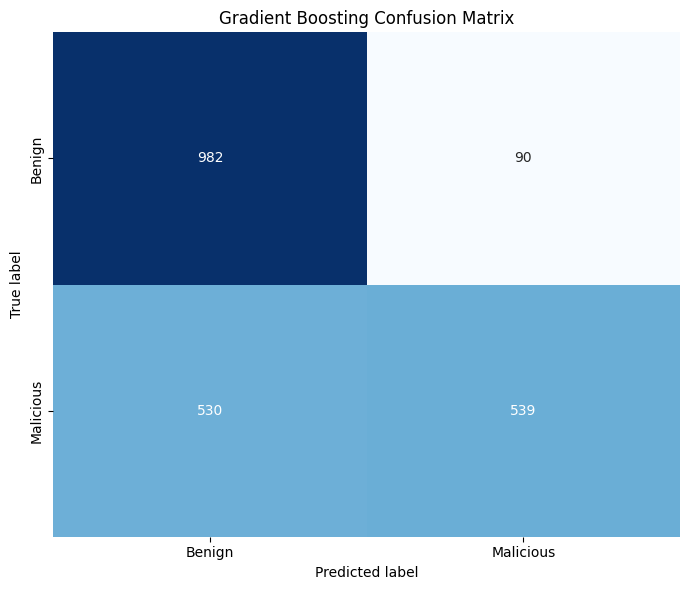

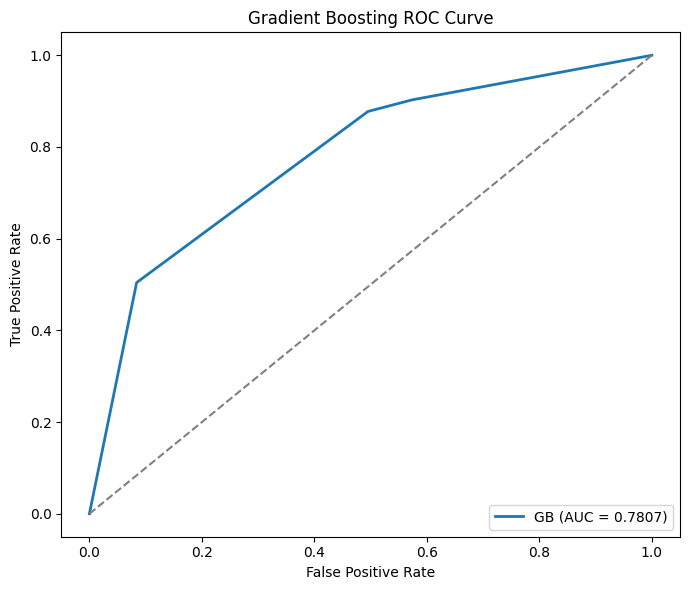


Gradient Boosting results
---------------------------------------------
Train Accuracy: 0.71208329
Validation Accuracy: 0.70621205
Test Accuracy: 0.71041569
Weighted Precision: 0.75304798
Weighted Recall: 0.71041569
Weighted F1 Score: 0.69755095
ROC AUC: 0.78067494
Cohen's Kappa: 0.42049650
Training Time (s): 9.65320684
Validation Prediction Time (s): 0.01729961
Test Prediction Time (s): 0.01710061

Model and preprocessing saved at: GB_best_model_17_features.pkl


In [10]:
import time
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.sparse import csr_matrix, hstack
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_fscore_support,
    cohen_kappa_score
)


# ============================================================
# Configuration
# ============================================================

file_path = "FinalCombinedBenignMaliciousDataset-v4 17F.csv"
target_column = "Level"

selected_features = [
    "IO_Operations",
    "File_Operations",
    "Time_Operations",
    "Process_Operations",
    "Write_Processes",
    "Read_Data_Transfer",
    "Local_Port_Access",
    "Remote_Port_Access",
    "Total_Dependencies",
    "Direct_Dependencies",
    "Indirect_Dependencies",
    "Pattern_1",
    "Pattern_2",
    "Pattern_3",
    "Pattern_4",
    "Pattern_5",
    "Pattern_6"
]


# ============================================================
# Load and validate dataset
# ============================================================

data = pd.read_csv(file_path)

required_columns = selected_features + [target_column]

missing_columns = [
    column for column in required_columns
    if column not in data.columns
]

if missing_columns:
    raise ValueError(
        f"The following required columns are missing: {missing_columns}"
    )

# Keep only the selected 17 predictors and target
data = data[required_columns].copy()

X_raw = data[selected_features].copy()
y = data[target_column].copy()


# ============================================================
# Split data before preprocessing
# ============================================================

X_train_raw, X_temp_raw, y_train, y_temp = train_test_split(
    X_raw,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val_raw, X_test_raw, y_val, y_test = train_test_split(
    X_temp_raw,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print(f"Dataset shape: {data.shape}")
print(f"Total selected features: {len(selected_features)}")
print(f"Training shape: {X_train_raw.shape}")
print(f"Validation shape: {X_val_raw.shape}")
print(f"Test shape: {X_test_raw.shape}")

# ============================================================
# Identify categorical and numerical features
# ============================================================

categorical_columns = [
    column for column in selected_features
    if X_train_raw[column].dtype == "object"
]

numerical_columns = [
    column for column in selected_features
    if column not in categorical_columns
]


# ============================================================
# Prepare categorical features
# ============================================================

def combine_categorical_columns(frame):
    """Combine the selected categorical attributes into text."""

    if not categorical_columns:
        return pd.Series("", index=frame.index)

    return (
        frame[categorical_columns]
        .fillna("")
        .astype(str)
        .agg(" ".join, axis=1)
    )


train_text = combine_categorical_columns(X_train_raw)
validation_text = combine_categorical_columns(X_val_raw)
test_text = combine_categorical_columns(X_test_raw)

# Fit vectorizer using training data only
vectorizer = CountVectorizer(
    ngram_range=(2, 3),
    lowercase=False
)

X_train_categorical = vectorizer.fit_transform(train_text)
X_val_categorical = vectorizer.transform(validation_text)
X_test_categorical = vectorizer.transform(test_text)


# ============================================================
# Prepare numerical features
# ============================================================

def prepare_numerical_features(frame):
    numerical_frame = frame[numerical_columns].copy()

    for column in numerical_columns:
        numerical_frame[column] = pd.to_numeric(
            numerical_frame[column],
            errors="coerce"
        )

    return numerical_frame.fillna(0.0).astype(float)


X_train_numerical = prepare_numerical_features(X_train_raw)
X_val_numerical = prepare_numerical_features(X_val_raw)
X_test_numerical = prepare_numerical_features(X_test_raw)

X_train_numerical_sparse = csr_matrix(
    X_train_numerical.values
)

X_val_numerical_sparse = csr_matrix(
    X_val_numerical.values
)

X_test_numerical_sparse = csr_matrix(
    X_test_numerical.values
)


# ============================================================
# Combine numerical and categorical inputs
# ============================================================

X_train_sparse = hstack(
    [X_train_numerical_sparse, X_train_categorical],
    format="csr"
)

X_val_sparse = hstack(
    [X_val_numerical_sparse, X_val_categorical],
    format="csr"
)

X_test_sparse = hstack(
    [X_test_numerical_sparse, X_test_categorical],
    format="csr"
)


# GradientBoostingClassifier requires dense input
X_train = X_train_sparse.toarray()
X_val = X_val_sparse.toarray()
X_test = X_test_sparse.toarray()

print(f"Training matrix memory: {X_train.nbytes / 1024**2:.2f} MB")
print(f"Validation matrix memory: {X_val.nbytes / 1024**2:.2f} MB")
print(f"Test matrix memory: {X_test.nbytes / 1024**2:.2f} MB")


# ============================================================
# Initialize and train Gradient Boosting model
# ============================================================

gb_model = GradientBoostingClassifier(
    n_estimators=10,
    max_depth=2,
    learning_rate=0.01,
    random_state=42
)

start_train_time = time.perf_counter()
gb_model.fit(X_train, y_train)
training_time = time.perf_counter() - start_train_time


# ============================================================
# Predictions and prediction times
# ============================================================

y_train_pred = gb_model.predict(X_train)

start_validation_time = time.perf_counter()
y_val_pred = gb_model.predict(X_val)
validation_time = time.perf_counter() - start_validation_time

start_test_time = time.perf_counter()
y_test_pred = gb_model.predict(X_test)
test_time = time.perf_counter() - start_test_time

y_test_probability = gb_model.predict_proba(X_test)[:, 1]


# ============================================================
# Evaluation metrics
# ============================================================

train_accuracy = accuracy_score(y_train, y_train_pred)
validation_accuracy = accuracy_score(y_val, y_val_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

precision, recall, f1, _ = precision_recall_fscore_support(
    y_test,
    y_test_pred,
    average="weighted",
    zero_division=0
)

test_auc = roc_auc_score(y_test, y_test_probability)
kappa = cohen_kappa_score(y_test, y_test_pred)

confusion = confusion_matrix(
    y_test,
    y_test_pred,
    labels=[0, 1]
)

tn, fp, fn, tp = confusion.ravel()


# ============================================================
# Save complete inference pipeline
# ============================================================

model_path = "GB_best_model_17_features.pkl"

model_artifact = {
    "model": gb_model,
    "vectorizer": vectorizer,
    "selected_features": selected_features,
    "categorical_columns": categorical_columns,
    "numerical_columns": numerical_columns,
    "target_column": target_column
}

joblib.dump(model_artifact, model_path)


# ============================================================
# Confusion matrix
# ============================================================

plt.figure(figsize=(7, 6))

sns.heatmap(
    confusion,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Benign", "Malicious"],
    yticklabels=["Benign", "Malicious"]
)

plt.title("Gradient Boosting Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()

plt.savefig(
    "GB_Confusion_Matrix_17F.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# ROC curve
# ============================================================

fpr, tpr, _ = roc_curve(
    y_test,
    y_test_probability
)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"GB (AUC = {test_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="grey"
)

plt.title("Gradient Boosting ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()

plt.savefig(
    "GB_ROC_Curve_17F.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# Print results
# ============================================================

metrics = {
    "Train Accuracy": train_accuracy,
    "Validation Accuracy": validation_accuracy,
    "Test Accuracy": test_accuracy,
    "Weighted Precision": precision,
    "Weighted Recall": recall,
    "Weighted F1 Score": f1,
    "ROC AUC": test_auc,
    "Cohen's Kappa": kappa,
    "Training Time (s)": training_time,
    "Validation Prediction Time (s)": validation_time,
    "Test Prediction Time (s)": test_time
}

print("\nGradient Boosting results")
print("-" * 45)

for metric, value in metrics.items():
    if isinstance(value, (int,)):
        print(f"{metric}: {value}")
    else:
        print(f"{metric}: {value:.8f}")

print(f"\nModel and preprocessing saved at: {model_path}")